In [1]:
import numpy as np
import pandas as pd
import torch
import xarray as xr
import matplotlib.pyplot as plt
import os

In [2]:
path = "data/fluxnet_div_ross.nc"

with xr.open_dataset(path) as _ds:
    ds = _ds.load()

# Construct

In [4]:
fluxnet_bmb = ds.fluxnet_div - ds.noel_smb + ds.icesat_dhdt

In [21]:
fluxnet_bmb

print(np.nanmin(ds.noel_smb), np.nanmax(ds.noel_smb))
print(np.nanmin(ds.fluxnet_div), np.nanmax(ds.fluxnet_div))
print(np.nanmin(ds.icesat_dhdt), np.nanmax(ds.icesat_dhdt))

0.0 0.40648967
-19.347698 14.015467
-80.21221227044462 62.036267439524366


In [5]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

In [26]:
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

X, Y = xr.broadcast(target_grid_mask.x, target_grid_mask.y)

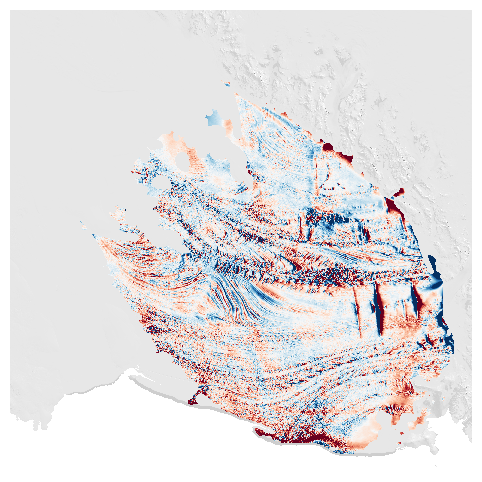

In [28]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
pcm = ax.pcolormesh(
    X.values,
    Y.values,
    # mm -> m
    fluxnet_bmb.values,
    cmap = "RdBu",
    vmin = -3,
    vmax = 3,
    alpha = 1.0,
    zorder = 1,
)

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/fluxnet_bmb_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# Todo:
wrong orientation